In [1]:
# Базовые библиотеки
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict
import json
from pathlib import Path

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Датасеты / трансформации
import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [2]:
seed = 42
def set_seed(seed) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [3]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_loss_only_save(history: dict, title: str = "", filename: str = "curves_best.png") -> None:
 
    save_dir = "artifacts/figures"
    os.makedirs(save_dir, exist_ok=True)
    
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], 'b-', label="train_loss", linewidth=2)
    plt.plot(epochs, history["val_loss"], 'r-', label="val_loss", linewidth=2)
    
    best_epoch = np.argmin(history["val_loss"]) + 1
    plt.axvline(x=best_epoch, color='g', linestyle='--', alpha=0.5,
                label=f'best epoch ({best_epoch})')
    
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title if title else "Training History")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()
    
    print(f"✅ График loss сохранен: {save_path}")
    

In [4]:
# Трансформации: ToTensor и Normalize
# KMNIST  уже в [0,1] после ToTensor, но нормализация помогает обучению.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # mean/std для 1 канала
])

# Скачиваем датасет
train_full = torchvision.datasets.EMNIST (
    root="./data", train=True, download=True, transform=transform, split="balanced"
)
test_ds = torchvision.datasets.EMNIST (
    root="./data", train=False, download=True, transform=transform, split="balanced"
)

class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))
     

classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
train size: 112800
test size: 18800


In [5]:
# Размер батча подстроим под наличие GPU
BATCH_SIZE = 256 if device.type == "cuda" else 64

# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2

# train/val split
val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([64, 1, 28, 28]) torch.float32
y_batch: torch.Size([64]) torch.int64


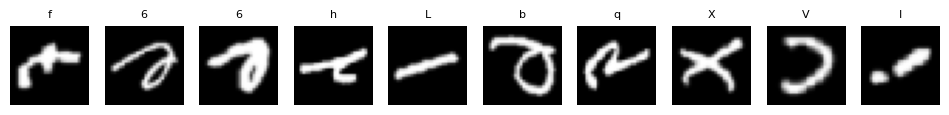

In [6]:
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

In [7]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Быстрый sanity-check по форме
model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

logits: torch.Size([64, 47])


In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [9]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [10]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

In [11]:
def log_experiment(
    experiment_id: str,
    dataset: str,
    seed: int,
    model: MLP,
    history: Dict[str, list],
    epochs_trained: int,
    lr: float,
    runs_file: str = "artifacts/runs.csv",
    momentum: float = 0.0,
    weight_decay: float = 0.0,
    optimizer_name: str = "Adam"
):

    linear_layers = []
    for layer in model.net:
        if isinstance(layer, nn.Linear):
            linear_layers.append(layer)
    
    # Если есть хотя бы 2 линейных слоя (входной + скрытые + выходной)
    if len(linear_layers) >= 2:
        # Берем все выходные размеры, кроме последнего (это и есть скрытые слои)
        hidden_dims = [layer.out_features for layer in linear_layers[:-1]]
    else:
        hidden_dims = "unknown"

    act_name = next((layer for layer in model.net if isinstance(layer, (nn.ReLU, nn.Tanh, nn.GELU))), 'relu').__class__.__name__.lower()
    dropout = any(isinstance(layer, nn.Dropout) for layer in model.net)
    batchnorm = any(isinstance(layer, nn.BatchNorm1d) for layer in model.net)
    early_stopping_used = len(history["val_acc"]) < epochs_trained
    
    hidden_dims_str = str(hidden_dims) if hidden_dims != "unknown" else "unknown"
    model_summary = f"hidden={hidden_dims_str} / {act_name} / dropout={dropout} / batchnorm={batchnorm} / earlystop={early_stopping_used}"

    best_idx = np.argmax(history["val_acc"])
    best_val_acc = max(history["val_acc"])
    best_val_loss = history["val_loss"][best_idx]

    row = {
        "experiment_id": experiment_id,
        "dataset": dataset,
        "seed": seed,
        "model_summary": model_summary,
        "optimizer": optimizer_name,
        "lr": lr,
        "momentum": momentum,
        "weight_decay": weight_decay,
        "epochs_trained": epochs_trained,
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss
    }
    
    # Сохранить в CSV (append mode)
    df_new = pd.DataFrame([row])
    try:
        df_existing = pd.read_csv(runs_file)
        df = pd.concat([df_existing, df_new], ignore_index=True)
    except FileNotFoundError:
        df = df_new
    
    df.to_csv(runs_file, index=False)
    print(f"✅ {experiment_id} сохранен в {runs_file}")
    print(f"   Best val_acc: {best_val_acc:.4f} на эпохе {best_idx+1}")

epoch 01/20 | train loss=1.1346, acc=0.6653 | val loss=0.7389, acc=0.7697
epoch 02/20 | train loss=0.6577, acc=0.7873 | val loss=0.6159, acc=0.8018
epoch 03/20 | train loss=0.5585, acc=0.8136 | val loss=0.5520, acc=0.8234
epoch 04/20 | train loss=0.5054, acc=0.8280 | val loss=0.5604, acc=0.8174
epoch 05/20 | train loss=0.4709, acc=0.8375 | val loss=0.5368, acc=0.8267
epoch 06/20 | train loss=0.4432, acc=0.8452 | val loss=0.5149, acc=0.8347
epoch 07/20 | train loss=0.4227, acc=0.8497 | val loss=0.5132, acc=0.8340
epoch 08/20 | train loss=0.4063, acc=0.8548 | val loss=0.5246, acc=0.8336
epoch 09/20 | train loss=0.3914, acc=0.8584 | val loss=0.4953, acc=0.8398
epoch 10/20 | train loss=0.3758, acc=0.8633 | val loss=0.5308, acc=0.8272
epoch 11/20 | train loss=0.3641, acc=0.8663 | val loss=0.5271, acc=0.8287
epoch 12/20 | train loss=0.3581, acc=0.8667 | val loss=0.5181, acc=0.8343
epoch 13/20 | train loss=0.3461, acc=0.8710 | val loss=0.5373, acc=0.8358
epoch 14/20 | train loss=0.3367, acc=0

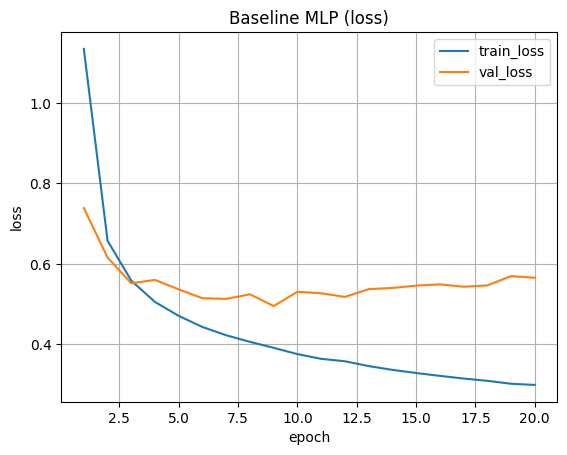

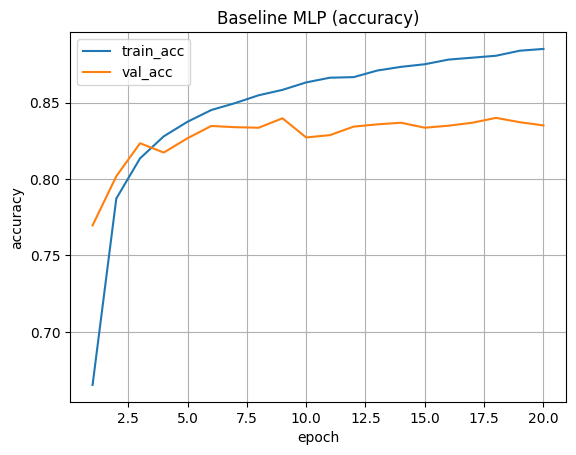

Baseline test: loss=0.6115, acc=0.8301
✅ E1 сохранен в artifacts/runs.csv
   Best val_acc: 0.8400 на эпохе 18


In [12]:
# Baseline: без Dropout и BatchNorm
set_seed(42)
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP")
test_loss, test_acc = evaluate(baseline, test_loader, criterion, device)
print(f"Baseline test: loss={test_loss:.4f}, acc={test_acc:.4f}")
log_experiment("E1", "EMNIST", seed, baseline, history_baseline, 20, 1e-3)

epoch 01/20 | train loss=1.5230, acc=0.5530 | val loss=0.8577, acc=0.7402
epoch 02/20 | train loss=1.0373, acc=0.6800 | val loss=0.7354, acc=0.7708
epoch 03/20 | train loss=0.9355, acc=0.7036 | val loss=0.6629, acc=0.7875
epoch 04/20 | train loss=0.8912, acc=0.7189 | val loss=0.6404, acc=0.7919
epoch 05/20 | train loss=0.8640, acc=0.7247 | val loss=0.6141, acc=0.8038
epoch 06/20 | train loss=0.8401, acc=0.7291 | val loss=0.6222, acc=0.8000
epoch 07/20 | train loss=0.8230, acc=0.7360 | val loss=0.6018, acc=0.8041
epoch 08/20 | train loss=0.8146, acc=0.7392 | val loss=0.5974, acc=0.8061
epoch 09/20 | train loss=0.7977, acc=0.7427 | val loss=0.5721, acc=0.8129
epoch 10/20 | train loss=0.7893, acc=0.7446 | val loss=0.5777, acc=0.8119
epoch 11/20 | train loss=0.7796, acc=0.7477 | val loss=0.5642, acc=0.8168
epoch 12/20 | train loss=0.7641, acc=0.7519 | val loss=0.5642, acc=0.8136
epoch 13/20 | train loss=0.7634, acc=0.7524 | val loss=0.5490, acc=0.8201
epoch 14/20 | train loss=0.7611, acc=0

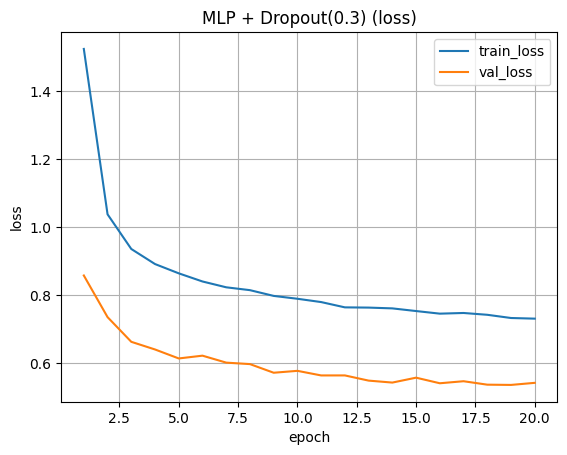

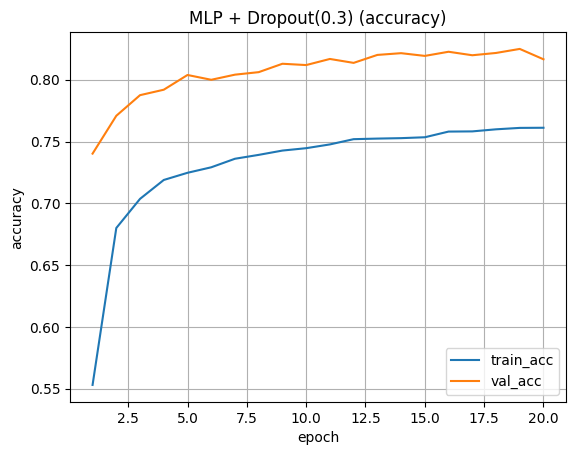

Dropout test: loss=0.5522, acc=0.8123
✅ E2 сохранен в artifacts/runs.csv
   Best val_acc: 0.8249 на эпохе 19


In [13]:
set_seed(42)
dropout_model = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout = fit(
    dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_dropout, title="MLP + Dropout(0.3)")
test_loss, test_acc = evaluate(dropout_model, test_loader, criterion, device)
print(f"Dropout test: loss={test_loss:.4f}, acc={test_acc:.4f}")
log_experiment("E2", "EMNIST", seed, dropout_model, history_dropout, 20, 1e-3)

epoch 01/20 | train loss=0.8882, acc=0.7433 | val loss=0.5715, acc=0.8195
epoch 02/20 | train loss=0.5273, acc=0.8230 | val loss=0.5173, acc=0.8276
epoch 03/20 | train loss=0.4588, acc=0.8432 | val loss=0.4683, acc=0.8421
epoch 04/20 | train loss=0.4170, acc=0.8526 | val loss=0.4688, acc=0.8450
epoch 05/20 | train loss=0.3862, acc=0.8612 | val loss=0.4497, acc=0.8500
epoch 06/20 | train loss=0.3662, acc=0.8683 | val loss=0.4488, acc=0.8519
epoch 07/20 | train loss=0.3454, acc=0.8733 | val loss=0.4559, acc=0.8487
epoch 08/20 | train loss=0.3271, acc=0.8784 | val loss=0.4533, acc=0.8485
epoch 09/20 | train loss=0.3147, acc=0.8816 | val loss=0.4435, acc=0.8532
epoch 10/20 | train loss=0.3017, acc=0.8868 | val loss=0.4494, acc=0.8513
epoch 11/20 | train loss=0.2887, acc=0.8894 | val loss=0.4593, acc=0.8491
epoch 12/20 | train loss=0.2797, acc=0.8919 | val loss=0.4530, acc=0.8556
epoch 13/20 | train loss=0.2686, acc=0.8964 | val loss=0.4744, acc=0.8486
epoch 14/20 | train loss=0.2622, acc=0

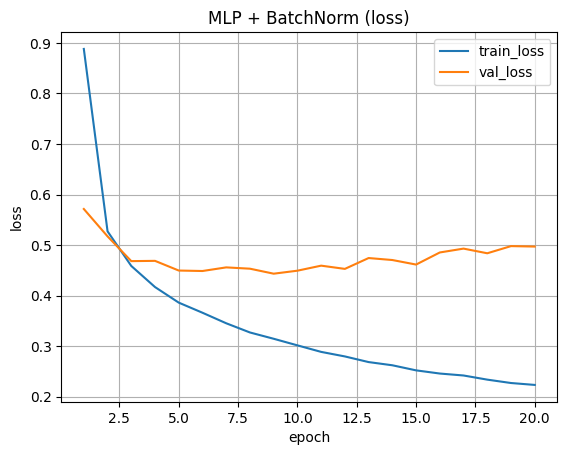

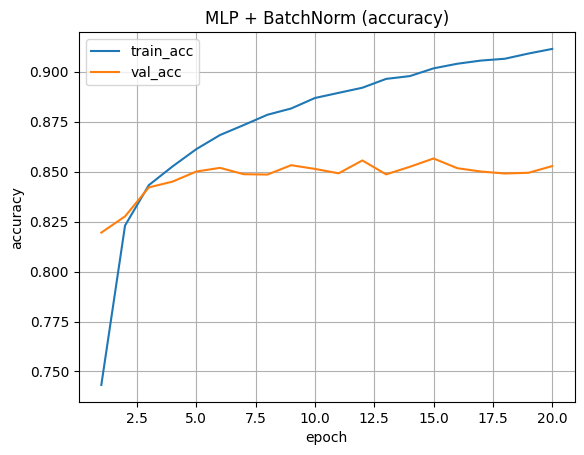

BatchNorm test: loss=0.5205, acc=0.8498
✅ E3 сохранен в artifacts/runs.csv
   Best val_acc: 0.8566 на эпохе 15


In [14]:
set_seed(42)
bn_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

history_bn = fit(
    bn_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_bn, title="MLP + BatchNorm")
test_loss, test_acc = evaluate(bn_model, test_loader, criterion, device)
print(f"BatchNorm test: loss={test_loss:.4f}, acc={test_acc:.4f}")
log_experiment("E3", "EMNIST", seed, bn_model, history_bn, 20, 1e-3)

epoch 01/50 | train loss=0.8882, acc=0.7433 | val loss=0.5715, acc=0.8195
epoch 02/50 | train loss=0.5273, acc=0.8230 | val loss=0.5173, acc=0.8276
epoch 03/50 | train loss=0.4588, acc=0.8432 | val loss=0.4683, acc=0.8421
epoch 04/50 | train loss=0.4170, acc=0.8526 | val loss=0.4688, acc=0.8450
epoch 05/50 | train loss=0.3862, acc=0.8612 | val loss=0.4497, acc=0.8500
epoch 06/50 | train loss=0.3662, acc=0.8683 | val loss=0.4488, acc=0.8519
epoch 07/50 | train loss=0.3454, acc=0.8733 | val loss=0.4559, acc=0.8487
epoch 08/50 | train loss=0.3271, acc=0.8784 | val loss=0.4533, acc=0.8485
epoch 09/50 | train loss=0.3147, acc=0.8816 | val loss=0.4435, acc=0.8532
epoch 10/50 | train loss=0.3017, acc=0.8868 | val loss=0.4494, acc=0.8513
epoch 11/50 | train loss=0.2887, acc=0.8894 | val loss=0.4593, acc=0.8491
epoch 12/50 | train loss=0.2797, acc=0.8919 | val loss=0.4530, acc=0.8556
epoch 13/50 | train loss=0.2686, acc=0.8964 | val loss=0.4744, acc=0.8486
epoch 14/50 | train loss=0.2622, acc=0

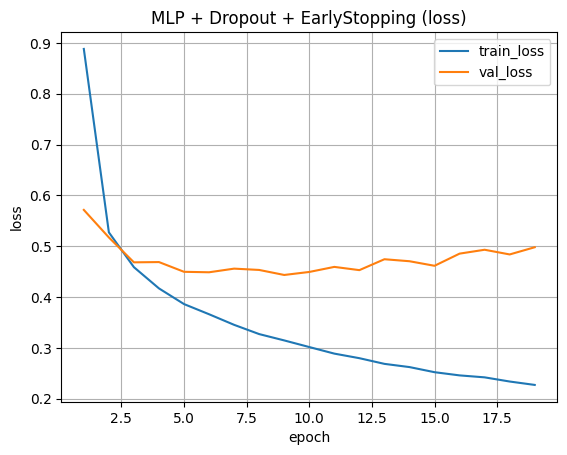

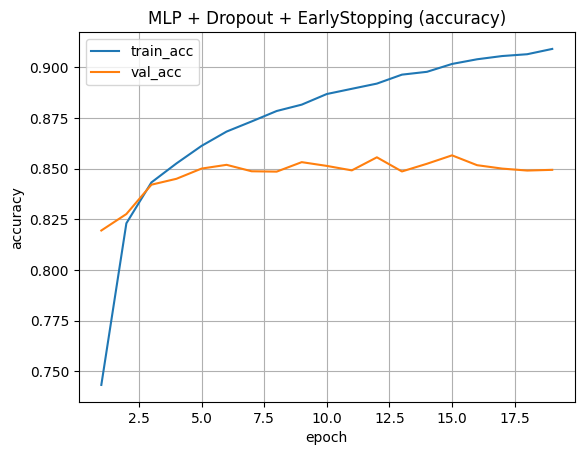

Combo test: loss=0.4921, acc=0.8506
✅ E4 сохранен в artifacts/runs.csv
   Best val_acc: 0.8566 на эпохе 15
✅ График loss сохранен: artifacts/figures\curves_best.png


In [15]:
set_seed(42)
combo_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combo_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_combo = fit(
    combo_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50,  # дадим больше эпох, но остановимся рано
    early_stopping=es,
    verbose=True
)

plot_history(history_combo, title="MLP + Dropout + EarlyStopping")
test_loss, test_acc = evaluate(combo_model, test_loader, criterion, device)
print(f"Combo test: loss={test_loss:.4f}, acc={test_acc:.4f}")
log_experiment("E4", "EMNIST", seed, combo_model, history_combo, 50, 1e-3)
plot_loss_only_save(history_combo, title="MLP + Dropout + EarlyStopping")

In [16]:
results = {
    "baseline": evaluate(baseline, test_loader, nn.CrossEntropyLoss(), device)[1],
    "dropout": evaluate(dropout_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "batchnorm": evaluate(bn_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "combo": evaluate(combo_model, test_loader, nn.CrossEntropyLoss(), device)[1],
}

for k, v in results.items():
    print(f"{k:>9}: test_acc={v:.4f}")
     

 baseline: test_acc=0.8301
  dropout: test_acc=0.8123
batchnorm: test_acc=0.8498
    combo: test_acc=0.8506


In [17]:
def save_best_model(model, history, config, filename="best_model.pt", config_file="best_config.json"):
    """
    Сохраняет лучшую модель и её конфигурацию
    """
    # Создаем директорию если нужно
    Path("artifacts").mkdir(exist_ok=True)
    
    # Находим лучшую эпоху по validation accuracy
    best_epoch = np.argmax(history["val_acc"])
    best_val_acc = history["val_acc"][best_epoch]
    best_val_loss = history["val_loss"][best_epoch]
    
    # Сохраняем state_dict модели
    torch.save(model.state_dict(), f"artifacts/{filename}")
    print(f"✅ Модель сохранена в artifacts/{filename}")
    print(f"   Best val_acc: {best_val_acc:.4f} (эпоха {best_epoch+1})")
    
    # Сохраняем конфигурацию
    config.update({
        "best_epoch": int(best_epoch + 1),
        "best_val_accuracy": float(best_val_acc),
        "best_val_loss": float(best_val_loss),
        "timestamp": str(pd.Timestamp.now())
    })
    
    with open(f"artifacts/{config_file}", 'w') as f:
        json.dump(config, f, indent=4)
    print(f"✅ Конфиг сохранен в artifacts/{config_file}")

best_config = {
    "model_name": "E4",
    "dataset": "EMNIST",
    "seed": seed,
    "type": "MLP",
    "hidden_dims": [256, 128],
    "activation": "relu",
    "dropout_p": 0.0,
    "use_batchnorm": True,
    "input_dim": 28*28,
    "num_classes": 47,
    "optimizer": "Adam",
    "learning_rate": 1e-3,
    "momentum": 0.0,
    "weight_decay": 0.0,
    "batch_size": BATCH_SIZE,
    "early_stopping_patience": 4,
    "early_stopping_min_delta": 0.0005,
    "epochs": 50,
    "actual_epochs_trained": len(history_combo["train_loss"])
}

save_best_model(combo_model, history_combo, best_config)

✅ Модель сохранена в artifacts/best_model.pt
   Best val_acc: 0.8566 (эпоха 15)
✅ Конфиг сохранен в artifacts/best_config.json



📊 Эксперимент O1: Слишком большой LR (lr=0.1)
epoch 01/6 | train loss=1.1616, acc=0.6582 | val loss=0.8633, acc=0.7362
epoch 02/6 | train loss=0.8542, acc=0.7309 | val loss=0.7730, acc=0.7651
epoch 03/6 | train loss=0.8086, acc=0.7438 | val loss=0.7933, acc=0.7380
epoch 04/6 | train loss=0.7584, acc=0.7588 | val loss=0.6455, acc=0.7913
epoch 05/6 | train loss=0.7253, acc=0.7690 | val loss=0.7179, acc=0.7676
epoch 06/6 | train loss=0.7140, acc=0.7701 | val loss=0.7435, acc=0.7728
✅ O1 сохранен в artifacts/runs.csv
   Best val_acc: 0.7913 на эпохе 4


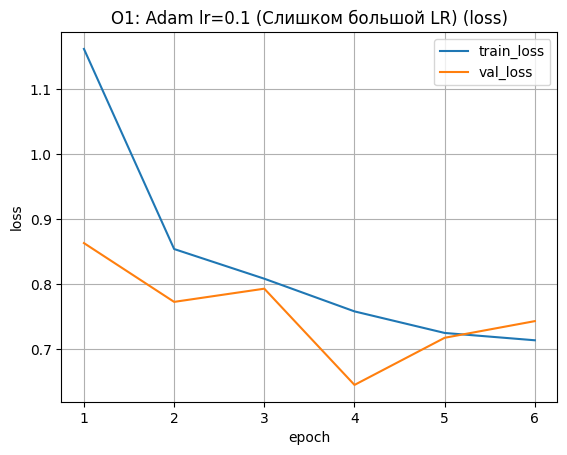

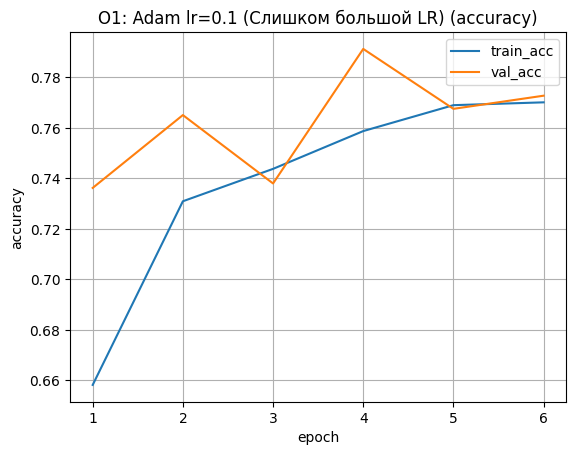


📊 Эксперимент O2: Слишком маленький LR (lr=1e-05)
epoch 01/6 | train loss=0.6956, acc=0.7705 | val loss=0.7205, acc=0.7826
epoch 02/6 | train loss=0.6752, acc=0.7778 | val loss=0.6934, acc=0.7903
epoch 03/6 | train loss=0.6500, acc=0.7847 | val loss=0.6835, acc=0.7913
epoch 04/6 | train loss=0.6345, acc=0.7900 | val loss=0.6610, acc=0.7969
epoch 05/6 | train loss=0.6220, acc=0.7940 | val loss=0.6544, acc=0.7980
epoch 06/6 | train loss=0.6104, acc=0.7984 | val loss=0.6458, acc=0.7987
✅ O2 сохранен в artifacts/runs.csv
   Best val_acc: 0.7987 на эпохе 6


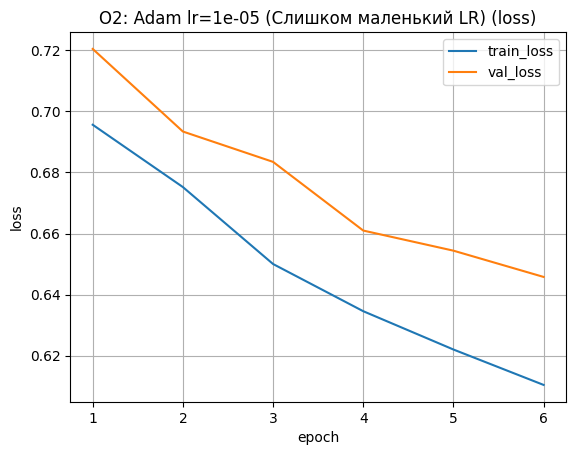

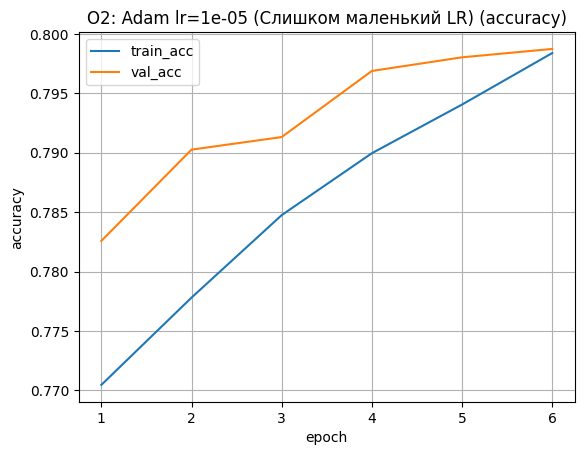

In [18]:
criterion = nn.CrossEntropyLoss()
EPOCHS = 6  # чисто для демонстрации этого достаточно

def run_experiment(exp_id, optimizer_kind, lr, weight_decay=0.0, momentum=0.9, epochs=EPOCHS):
    """Запускает эксперимент с той же архитектурой, что и combo_model"""
    model = combo_model
    
    # Создаем оптимизатор
    if optimizer_kind.lower() == "adam":
        opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_kind.lower() == "sgd":
        opt = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_kind}")
    
    # Обучаем модель
    hist = fit(model, train_loader, val_loader, opt, criterion, device, epochs=epochs, verbose=True)
    
    # Находим лучшие метрики
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")
    best_val_loss = float(np.nanmin(hist["val_loss"])) if len(hist["val_loss"]) else float("nan")
    
    # Логируем эксперимент
    log_experiment(
        experiment_id=exp_id,
        dataset="EMNIST",
        seed=seed,
        model=model,
        history=hist,
        epochs_trained=len(hist["train_loss"]),
        lr=lr
    )
    
    return {
        "exp_id": exp_id,
        "optimizer": optimizer_kind,
        "lr": lr,
        "weight_decay": weight_decay,
        "momentum": momentum if optimizer_kind.lower() == "sgd" else None,
        "epochs_ran": len(hist["val_acc"]),
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "history": hist,
    }

lr_experiments = [
    ("O1", "Слишком большой LR", 1e-1),   # слишком большой
    ("O2", "Слишком маленький LR", 1e-5), # слишком маленький
]

results_lr = []
for exp_id, description, lr in lr_experiments:
    print(f"\n📊 Эксперимент {exp_id}: {description} (lr={lr})")
    print("=" * 50)
    
    res = run_experiment(
        exp_id=exp_id, 
        optimizer_kind="adam", 
        lr=lr,
        epochs=EPOCHS
    )
    results_lr.append(res)
    
    # Используем существующую функцию plot_history для отображения
    plot_history(res["history"], title=f"{exp_id}: Adam lr={lr} ({description})")

In [19]:
rows = []
for r in results_lr:
    rows.append({
        "exp_id": r["exp_id"],
        "optimizer": r["optimizer"],
        "lr": r["lr"],
        "weight_decay": r["weight_decay"],
        "epochs_ran": r["epochs_ran"],
        "best_val_acc": r["best_val_acc"],
        "best_val_loss": r["best_val_loss"],
    })

df_lr = pd.DataFrame(rows).sort_values(by="best_val_acc", ascending=False)
display(df_lr)

,exp_id,optimizer,lr,weight_decay,epochs_ran,best_val_acc,best_val_loss
1,O2,adam,0.00001,0.0,6,0.798729,0.645764
0,O1,adam,0.10000,0.0,6,0.791314,0.645453


In [20]:
def plot_lr_extremes(results):
    # Фильтруем только O1 и O2
    o1_o2 = [r for r in results if r["exp_id"] in ['O1', 'O2']]
    
    # Настройки цветов
    colors = {'O1': 'red', 'O2': 'blue'}
    
    # График accuracy
    plt.figure()
    for res in o1_o2:
        exp_id = res["exp_id"]
        epochs = range(1, len(res["history"]["val_acc"]) + 1)
        plt.plot(epochs, res["history"]["val_acc"], 
                color=colors[exp_id], 
                label=f"{exp_id}: lr={res['lr']:.0e}")
    
    plt.xlabel("epoch")
    plt.ylabel("validation accuracy")
    plt.title("Effect of learning rate on accuracy")
    plt.legend()
    plt.grid(True)
    plt.savefig("artifacts/figures/curves_lr_extremes.png", dpi=150, bbox_inches="tight")
    plt.close()
    
    print("✅ График сохранен в artifacts/figures/curves_lr_extremes.png")


# Строим и сохраняем графики
plot_lr_extremes(results_lr)

✅ График сохранен в artifacts/figures/curves_lr_extremes.png



🚀 Запуск O3: SGD, lr=0.01, momentum=0.9, weight_decay=0.0001
   Эпох: 12
epoch 01/12 | train loss=0.5317, acc=0.8214 | val loss=0.5487, acc=0.8220
epoch 02/12 | train loss=0.5093, acc=0.8270 | val loss=0.5374, acc=0.8241
epoch 03/12 | train loss=0.5011, acc=0.8293 | val loss=0.5324, acc=0.8262
epoch 04/12 | train loss=0.4948, acc=0.8305 | val loss=0.5313, acc=0.8286
epoch 05/12 | train loss=0.4874, acc=0.8338 | val loss=0.5197, acc=0.8324
epoch 06/12 | train loss=0.4861, acc=0.8342 | val loss=0.5196, acc=0.8317
epoch 07/12 | train loss=0.4821, acc=0.8356 | val loss=0.5165, acc=0.8320
epoch 08/12 | train loss=0.4805, acc=0.8355 | val loss=0.5142, acc=0.8330
epoch 09/12 | train loss=0.4776, acc=0.8350 | val loss=0.5161, acc=0.8332
epoch 10/12 | train loss=0.4741, acc=0.8373 | val loss=0.5104, acc=0.8360
epoch 11/12 | train loss=0.4747, acc=0.8375 | val loss=0.5083, acc=0.8340
epoch 12/12 | train loss=0.4708, acc=0.8389 | val loss=0.5055, acc=0.8370
✅ O3 сохранен в artifacts/runs.csv
   

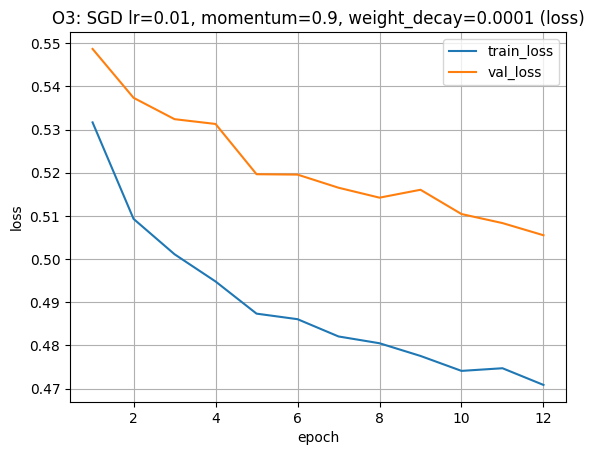

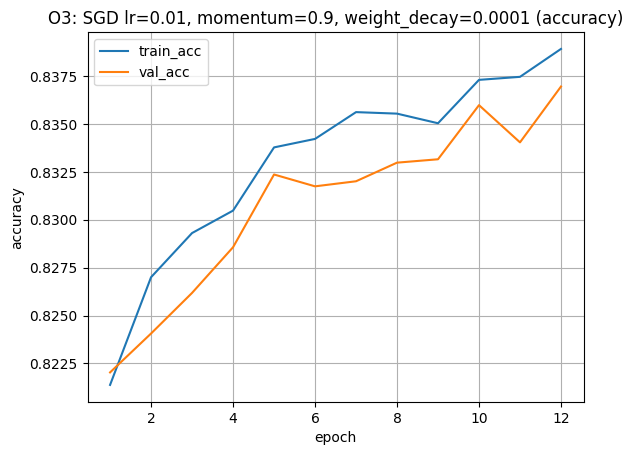


✅ O3 завершен. Best val_acc: 0.8370, Best val_loss: 0.5055


In [21]:
O3_LR = 1e-2  # Разумный learning rate для SGD (можно попробовать 1e-2 или 1e-3)
O3_MOMENTUM = 0.9
O3_WEIGHT_DECAY = 1e-4
EPOCHS_O3 = 12  # 12 эпох для демонстрации

# Создаем модель с той же архитектурой
model_o3 = combo_model

# Создаем оптимизатор SGD с momentum и weight decay
optimizer_o3 = optim.SGD(
    model_o3.parameters(), 
    lr=O3_LR, 
    momentum=O3_MOMENTUM, 
    weight_decay=O3_WEIGHT_DECAY
)

criterion = nn.CrossEntropyLoss()

print(f"\n🚀 Запуск O3: SGD, lr={O3_LR}, momentum={O3_MOMENTUM}, weight_decay={O3_WEIGHT_DECAY}")
print(f"   Эпох: {EPOCHS_O3}")

# Обучаем модель
history_o3 = fit(
    model_o3, train_loader, val_loader,
    optimizer_o3, criterion, device,
    epochs=EPOCHS_O3,
    early_stopping=None,
    verbose=True
)

# Находим лучшие метрики
best_val_acc_o3 = float(np.nanmax(history_o3["val_acc"])) if len(history_o3["val_acc"]) else float("nan")
best_val_loss_o3 = float(np.nanmin(history_o3["val_loss"])) if len(history_o3["val_loss"]) else float("nan")

# Логируем эксперимент
log_experiment(
    experiment_id="O3",
    dataset="EMNIST",
    seed=seed,
    model=model_o3,
    history=history_o3,
    epochs_trained=len(history_o3["train_loss"]),
    lr=O3_LR,
    momentum=O3_MOMENTUM,
    weight_decay=O3_WEIGHT_DECAY,
    optimizer_name="SGD"
)

# Отображаем графики
plot_history(history_o3, title=f"O3: SGD lr={O3_LR}, momentum={O3_MOMENTUM}, weight_decay={O3_WEIGHT_DECAY}")

print(f"\n✅ O3 завершен. Best val_acc: {best_val_acc_o3:.4f}, Best val_loss: {best_val_loss_o3:.4f}")

In [22]:
# Финальныя оценка лучшей модели (E4) на тесте

# Оцениваем на тестовых данных
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(combo_model, test_loader, criterion, device)

print(f"\n📊 РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ:")
print(f"   Test Loss:     {test_loss:.4f}")
print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")


📊 РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ:
   Test Loss:     0.5269
   Test Accuracy: 0.8285 (82.85%)
